# SentinelAI — 01 EDA & Cleaning (Methodology v2)

هذا الـNotebook يراجع العينة المحلية من CSE-CIC-IDS2018، ينظفها ويعرض EDA بدون تدريب.

**تصحيح مهم عن النسخة السابقة:** إذا كانت `Label` رقمية (كما في ملف المشروع الحالي)، فإن
`1 = Benign` والباقي يبقى بأسماء عامة `Attack_<code>` حتى يتوفر mapping موثوق. لذلك لا نبحث
عن النص `"benign"` داخل عمود رقمي، لأن ذلك كان يعطي Benign = 0% بشكل خاطئ.

> لا نخترع أسماء هجمات. إذا كان المصدر يحتوي أسماء نصية أصلية، نحافظ عليها.

In [ ]:
from pathlib import Path
import json
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

cwd = Path.cwd()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("ضع ملف CSV الخاص بالعينة داخل data/ ثم أعد التشغيل.")

print("CSV files:")
for p in csv_files:
    print(" -", p.name)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

cwd = Path.cwd()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("ضع ملف CSV الخاص بالعينة داخل data/ ثم أعد التشغيل.")

print("CSV files:")
for p in csv_files:
    print(" -", p.name)

ModuleNotFoundError: No module named 'numpy'

In [ ]:
df = pd.concat([pd.read_csv(p, low_memory=False) for p in csv_files], ignore_index=True)
df.columns = df.columns.str.strip()

if "Label" not in df.columns:
    raise KeyError("Label column not found.")

print(f"Raw shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df["Label"].value_counts(dropna=False).head(20))

Raw shape: 1,252,846 rows × 79 columns
Label
1     971016
4     137185
5      57507
2      38703
3      37323
6       8377
7       2234
8        332
9        103
10        55
11        11
Name: count, dtype: int64


In [ ]:
# Clean infinities / missing values / duplicates without converting Label to text first.
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

before = len(df)
missing_rows = int(df.isna().any(axis=1).sum())
df = df.dropna().drop_duplicates().reset_index(drop=True)

print(f"Rows before cleaning: {before:,}")
print(f"Rows containing missing/inf before drop: {missing_rows:,}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Removed total: {before - len(df):,}")

Rows before cleaning: 1,252,846
Rows containing missing/inf before drop: 0
Rows after cleaning: 1,135,409
Removed total: 117,437


In [ ]:
# Robust label interpretation.
label_numeric = pd.to_numeric(df["Label"], errors="coerce")
numeric_label_mode = label_numeric.notna().all()

if numeric_label_mode:
    if not np.allclose(label_numeric, np.round(label_numeric)):
        raise ValueError("Numeric labels are not integer-like.")
    label_code = label_numeric.astype(int)
    unique_codes = sorted(label_code.unique())
    label_mapping = {int(c): ("Benign" if int(c) == 1 else f"Attack_{int(c)}")
                     for c in unique_codes}
    label_name = label_code.map(label_mapping)
    is_benign = label_code.eq(1)
    label_status = "numeric_generic_mapping"
else:
    label_name = df["Label"].astype(str).str.strip()
    is_benign = label_name.str.casefold().eq("benign")
    # Text labels are already semantic names from the source.
    ordered = list(pd.unique(label_name))
    benign_names = [x for x in ordered if x.casefold() == "benign"]
    attack_names = [x for x in ordered if x.casefold() != "benign"]
    label_mapping = {}
    next_code = 1
    if benign_names:
        label_mapping[1] = benign_names[0]
        next_code = 2
    for name in attack_names:
        label_mapping[next_code] = name
        next_code += 1
    label_status = "text_labels_preserved"

df["Label_Name"] = label_name
df["_Traffic"] = np.where(is_benign, "Benign", "Attack")

print("Label mode:", label_status)
print(f"Benign: {is_benign.mean():.2%}")
print(f"Attack: {(~is_benign).mean():.2%}")
print("\nClass distribution:")
print(df["Label_Name"].value_counts())

Label mode: numeric_generic_mapping
Benign: 77.51%
Attack: 22.49%

Class distribution:
Label_Name
Benign       880060
Attack_4     124280
Attack_5      52051
Attack_2      35127
Attack_3      33817
Attack_6       7598
Attack_7       2028
Attack_8        301
Attack_9         91
Attack_10        46
Attack_11        10
Name: count, dtype: int64


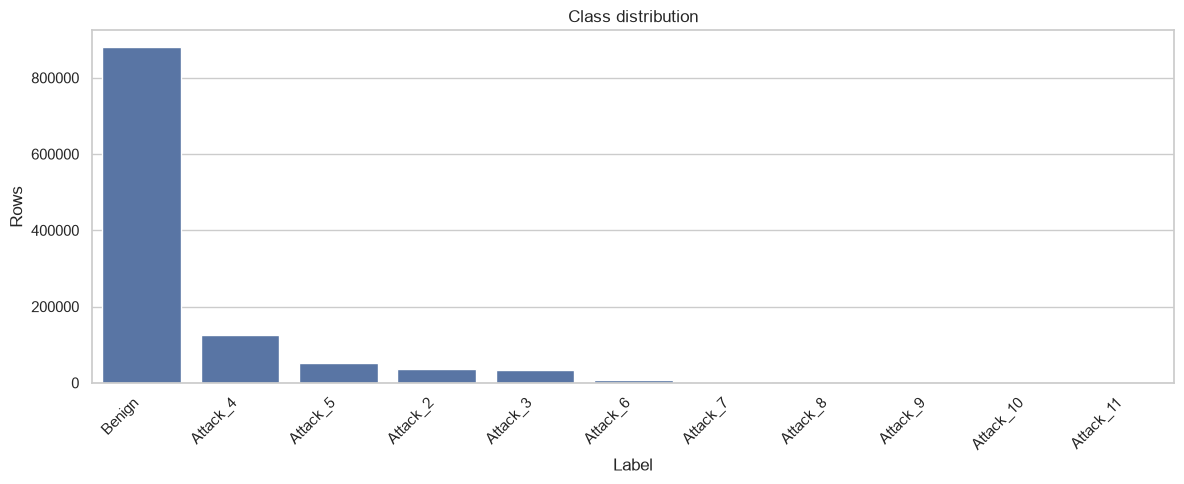

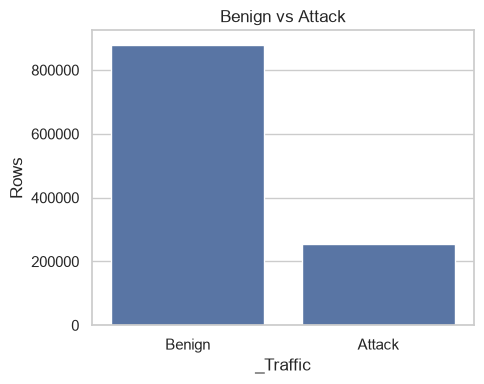

In [ ]:
# Class distribution
counts = df["Label_Name"].value_counts()
plt.figure(figsize=(12, 5))
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution")
plt.ylabel("Rows")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

# Benign vs attack
traffic_counts = df["_Traffic"].value_counts()
plt.figure(figsize=(5, 4))
sns.barplot(x=traffic_counts.index, y=traffic_counts.values)
plt.title("Benign vs Attack")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

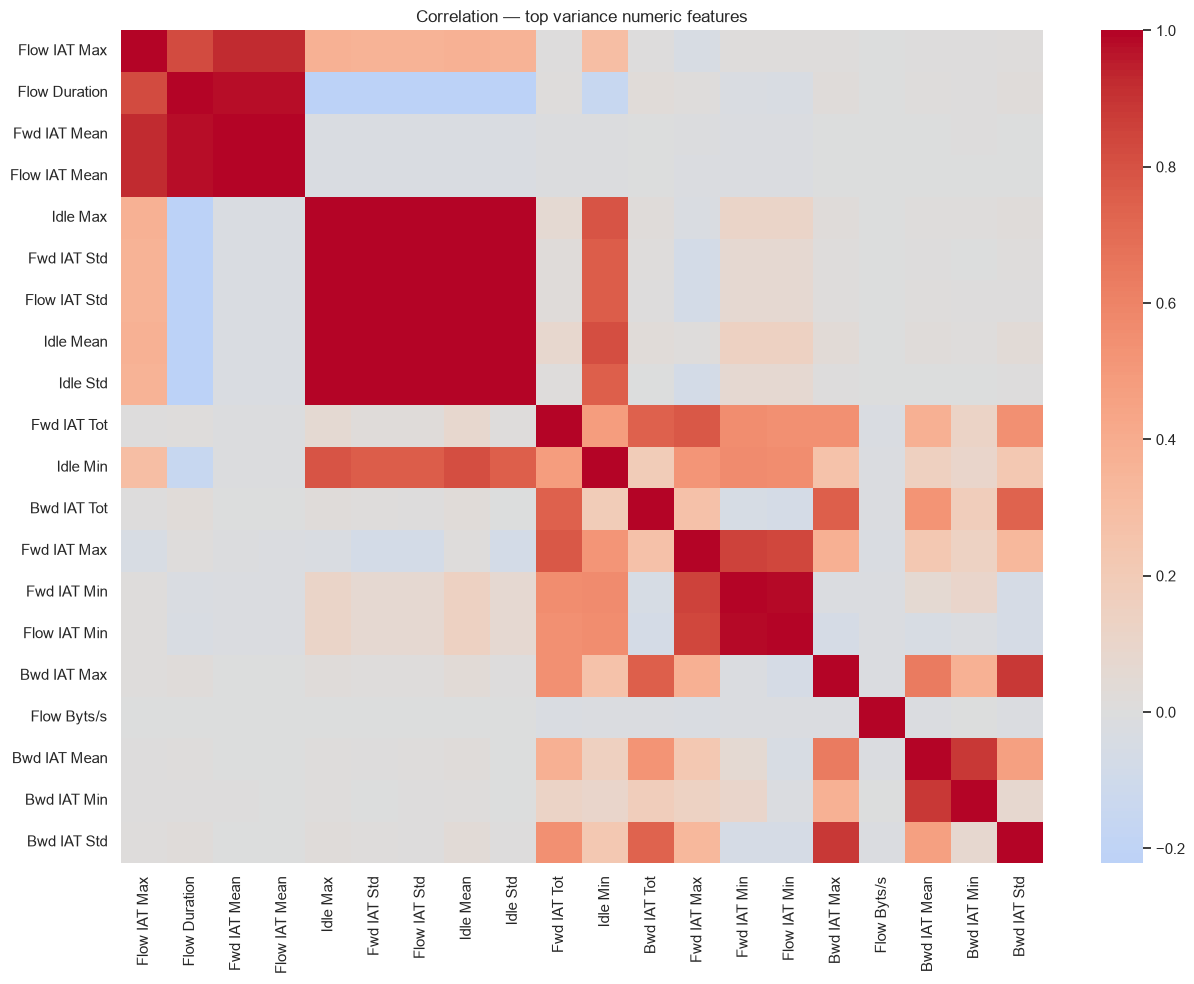

['Flow IAT Max',
 'Flow Duration',
 'Fwd IAT Mean',
 'Flow IAT Mean',
 'Idle Max',
 'Fwd IAT Std',
 'Flow IAT Std',
 'Idle Mean',
 'Idle Std',
 'Fwd IAT Tot']

In [ ]:
# Correlation on a manageable, high-variance subset of numeric features.
excluded = {"Label", "Label_Name", "_Traffic", "Unnamed: 0"}
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in excluded]

variances = df[feature_cols].var().sort_values(ascending=False)
top_features = variances.head(min(20, len(variances))).index.tolist()

corr = df[top_features].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation — top variance numeric features")
plt.tight_layout()
plt.show()

top_features[:10]

In [ ]:
# Persist only metadata; the cleaned CSV remains local and is not committed.
summary = {
    "rows_after_cleaning": int(len(df)),
    "columns": int(df.shape[1]),
    "label_mode": label_status,
    "benign_ratio": float(is_benign.mean()),
    "attack_ratio": float((~is_benign).mean()),
    "classes": {str(k): v for k, v in label_mapping.items()},
    "semantic_attack_mapping_verified": bool(not numeric_label_mode),
}
(PROCESSED_DIR / "eda_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "rows_after_cleaning": 1135409,
  "columns": 81,
  "label_mode": "numeric_generic_mapping",
  "benign_ratio": 0.7751039493257496,
  "attack_ratio": 0.22489605067425042,
  "classes": {
    "1": "Benign",
    "2": "Attack_2",
    "3": "Attack_3",
    "4": "Attack_4",
    "5": "Attack_5",
    "6": "Attack_6",
    "7": "Attack_7",
    "8": "Attack_8",
    "9": "Attack_9",
    "10": "Attack_10",
    "11": "Attack_11"
  },
  "semantic_attack_mapping_verified": false
}


## الاستنتاج

- عند الترميز الرقمي الحالي، `1 = Benign` فقط هو الاسم الموثوق داخل المشروع.
- `Attack_2 ... Attack_11` أسماء مؤقتة وليست أسماء عائلات هجمات مؤكدة.
- أي نسب أو رسوم Benign/Attack في هذا الملف تعتمد على الترميز الصحيح بدل مقارنة أرقام بنصوص.